In [33]:
import os
from pycocotools.coco import COCO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [34]:
# 파일 경로 설정
data_root = r"D:\Dev\WheelScan\data"
#data_root = r"/Users/dongbae/Dev/WheelScan/data"
train_img_dir = os.path.join(data_root, "train", "images")
train_label_dir = os.path.join(data_root, "train", "labels")

In [35]:
def create_dataframe(label_dir, train_img_dir):
    # 카테고리 매핑
    category_map = {
        0: 'crack',
        1: 'discoloration',
        2: 'flat',
        3: 'shelling',
        4: 'spalling',
        5: 'wheel'
    }

    annotations = []
    label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    image_sizes = {}
    
    for label_file in label_files:
        image_name = os.path.splitext(label_file)[0] + '.jpg'
        image_id = os.path.splitext(label_file)[0]
        image_path = os.path.join(train_img_dir, image_name)
        try:
            with Image.open(image_path) as img:
                img_width, img_height = img.size
                image_sizes[image_name] = {'width': img_width, 'height': img_height}
        except Exception as e:
            print(f"Error reading {image_path}: {e}")
            image_sizes[image_name] = {'width': None, 'height': None}
        
        with open(os.path.join(label_dir, label_file), 'r') as f:
            lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            
            class_id = int(parts[0])
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])

            class_name = category_map.get(class_id, f"class_{class_id}")
            
            annotations.append({
                'image_id': image_id,
                'file_name': image_name,
                'category_id': class_id,
                'category_name': class_name,
                'x_center': x_center,
                'y_center': y_center,
                'width': width,
                'height': height,
                'image_width': image_sizes[image_name]['width'],
                'image_height': image_sizes[image_name]['height']
            })
    
    df = pd.DataFrame(annotations)
    return df

In [36]:
df = create_dataframe(train_label_dir, train_img_dir)
print(df.head())

                                        image_id  \
0  D0001_JPG.rf.e834a2791d225bf4caa57619f75d9cb8   
1  D0001_JPG.rf.e834a2791d225bf4caa57619f75d9cb8   
2  D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055   
3  D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055   
4  D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055   

                                           file_name  category_id  \
0  D0001_JPG.rf.e834a2791d225bf4caa57619f75d9cb8.jpg            4   
1  D0001_JPG.rf.e834a2791d225bf4caa57619f75d9cb8.jpg            4   
2  D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055.jpg            4   
3  D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055.jpg            4   
4  D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055.jpg            4   

  category_name  x_center  y_center     width    height  image_width  \
0      spalling  0.403442  0.594909  0.073539  0.152409          308   
1      spalling  0.379091  0.744000  0.097403  0.156409          308   
2      spalling  0.516070  0.472568  0.096006  0.094279 

In [37]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   image_id       499 non-null    object 
 1   file_name      499 non-null    object 
 2   category_id    499 non-null    int64  
 3   category_name  499 non-null    object 
 4   x_center       499 non-null    float64
 5   y_center       499 non-null    float64
 6   width          499 non-null    float64
 7   height         499 non-null    float64
 8   image_width    499 non-null    int64  
 9   image_height   499 non-null    int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 39.1+ KB
None


prefix
D    136
L     41
R     41
Name: image_id, dtype: int64


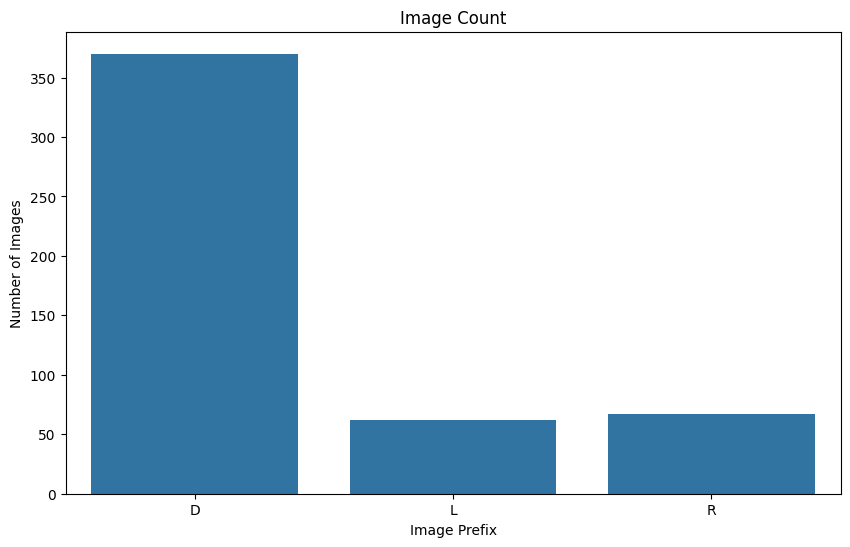

In [38]:
# image_id의 첫 글자 추출 (D, L, R)
df['prefix'] = df['image_id'].str[0]

# 각 prefix별 고유한 image_id 개수 세기
counts = df.groupby('prefix')['image_id'].nunique()

# 결과 출력
print(counts)

# 시각화
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='prefix')
plt.title('Image Count')
plt.xlabel('Image Prefix')
plt.ylabel('Number of Images')
plt.show()

In [39]:
# ✅ 1. prefix별 데이터프레임 분리
df_D = df[df['prefix'] == 'D'].copy()
df_LR = df[df['prefix'].isin(['L', 'R'])].copy()

# 결과 확인
print("D 데이터프레임 개수:", len(df_D))
print("L/R 데이터프레임 개수:", len(df_LR))

D 데이터프레임 개수: 370
L/R 데이터프레임 개수: 129


In [40]:
df.head()

,image_id,file_name,category_id,category_name,x_center,y_center,width,height,image_width,image_height,prefix
0,D0001_JPG.rf.e834a2791d225bf4caa57619f75d9cb8,D0001_JPG.rf.e834a2791d225bf4caa57619f75d9cb8.jpg,4,spalling,0.403442,0.594909,0.073539,0.152409,308,220,D
1,D0001_JPG.rf.e834a2791d225bf4caa57619f75d9cb8,D0001_JPG.rf.e834a2791d225bf4caa57619f75d9cb8.jpg,4,spalling,0.379091,0.744000,0.097403,0.156409,308,220,D
2,D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055,D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055.jpg,4,spalling,0.516070,0.472568,0.096006,0.094279,313,222,D
3,D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055,D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055.jpg,4,spalling,0.509201,0.372252,0.164601,0.072523,313,222,D
4,D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055,D0002_JPG.rf.a2794059ea4bf6fadbc41b798c8ff055.jpg,4,spalling,0.450927,0.287658,0.154313,0.067703,313,222,D


C:\Users\우리집\AppData\Local\Temp\ipykernel_25916\4031323262.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\우리집\AppData\Local\Temp\ipykernel_25916\4031323262.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(


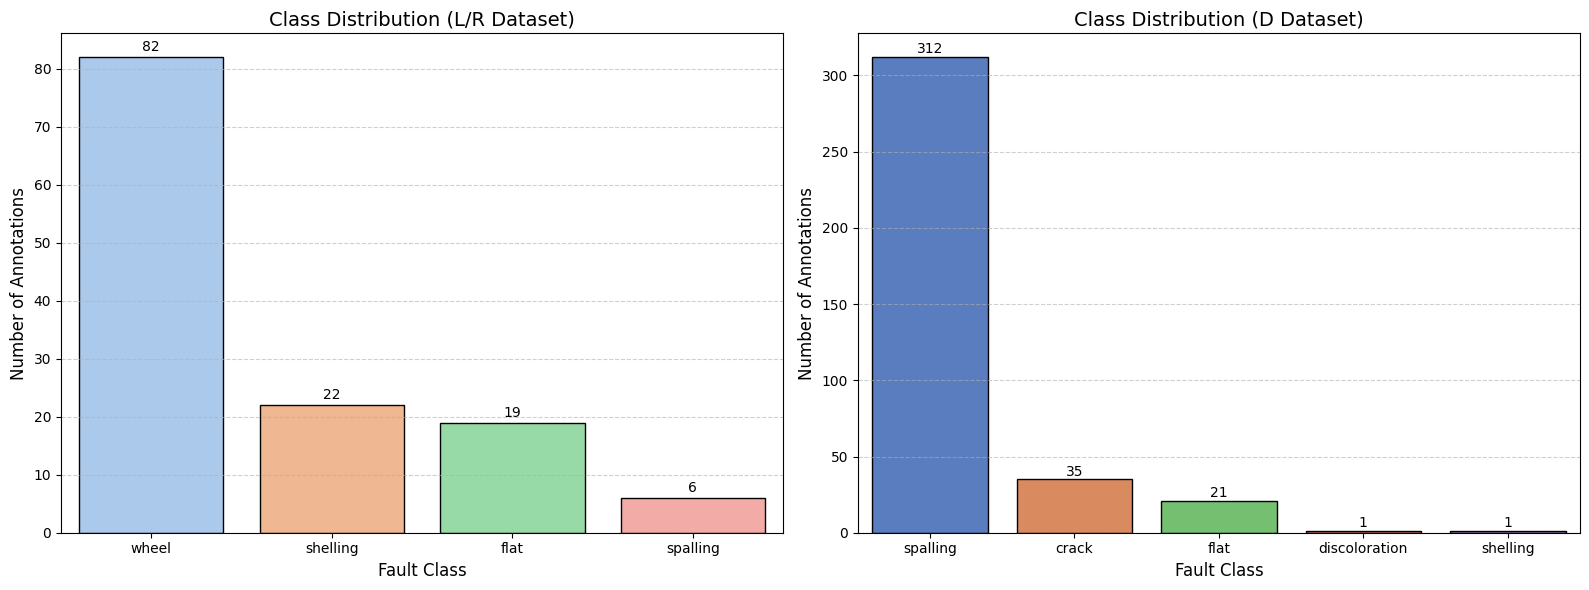

In [41]:
# ✅ 2. Figure 크기 설정
plt.figure(figsize=(16, 6))

# ----- (왼쪽) L/R 분포 -----
plt.subplot(1, 2, 1)
ax1 = sns.countplot(
    data=df_LR,
    x='category_name',
    order=df_LR['category_name'].value_counts().index,
    palette='pastel',
    edgecolor='black'
)
plt.title('Class Distribution (L/R Dataset)', fontsize=14)
plt.xlabel('Fault Class', fontsize=12)
plt.ylabel('Number of Annotations', fontsize=12)
#plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 막대 위에 개수 표시
for p in ax1.patches:
    ax1.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.5,
        f'{int(p.get_height())}',
        ha='center', va='bottom', fontsize=10
    )

# ----- (오른쪽) D 분포 -----
plt.subplot(1, 2, 2)
ax2 = sns.countplot(
    data=df_D,
    x='category_name',
    order=df_D['category_name'].value_counts().index,
    palette='muted',
    edgecolor='black'
)
plt.title('Class Distribution (D Dataset)', fontsize=14)
plt.xlabel('Fault Class', fontsize=12)
plt.ylabel('Number of Annotations', fontsize=12)
#plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 막대 위에 개수 표시
for p in ax2.patches:
    ax2.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.5,
        f'{int(p.get_height())}',
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

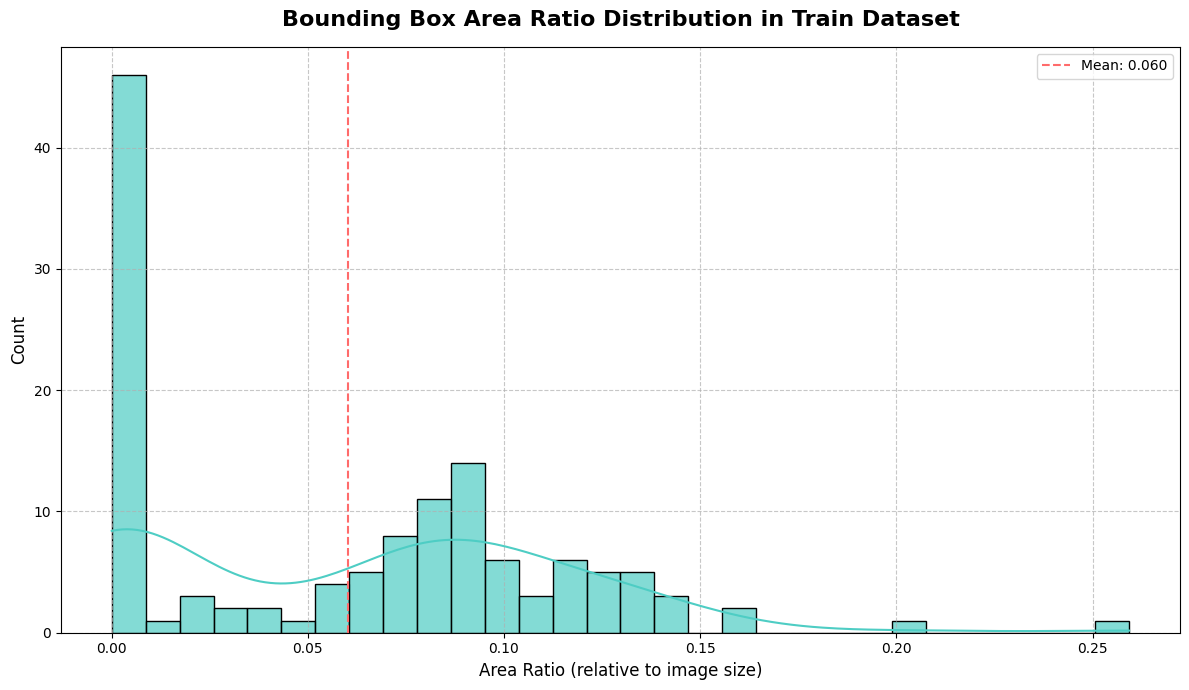

In [42]:
# 바운딩 박스가 이미지 내 차지하는 비율
df_LR['bbox_width_abs'] = df_LR['width'] * df_LR['image_width']
df_LR['bbox_height_abs'] = df_LR['height'] * df_LR['image_height']
# 바운딩 박스 면적 계산
df_LR['area'] = df_LR['bbox_width_abs'] * df_LR['bbox_height_abs']
# 이미지 전체 면적 대비 비율 계산
df_LR['area_ratio'] = df_LR['area'] / (df_LR['image_width'] * df_LR['image_height'])

# 바운딩 박스 면적 비율 분포 시각화
plt.figure(figsize=(12, 7))
sns.histplot(data=df_LR, x='area_ratio', bins=30, kde=True, color='#4ECDC4', alpha=0.7)
plt.title('Bounding Box Area Ratio Distribution in Train Dataset', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Area Ratio (relative to image size)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.axvline(df_LR['area_ratio'].mean(), color='#FF6B6B', linestyle='--', label=f'Mean: {df_LR["area_ratio"].mean():.3f}')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

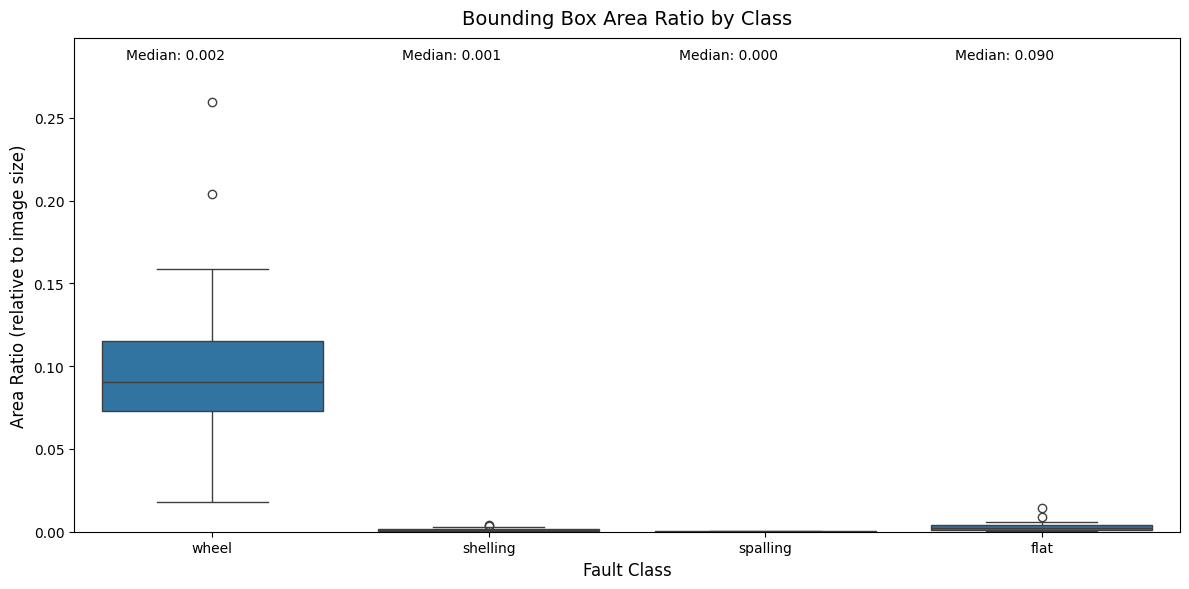


Bounding Box Area Ratio Statistics by Class:
               count      mean       std       min       25%       50%  \
category_name                                                            
flat            19.0  0.003423  0.003322  0.000623  0.001324  0.002349   
shelling        22.0  0.001272  0.000997  0.000170  0.000583  0.000971   
spalling         6.0  0.000105  0.000048  0.000054  0.000064  0.000099   
wheel           82.0  0.093562  0.038303  0.017718  0.073108  0.090219   

                    75%       max  
category_name                      
flat           0.003924  0.014412  
shelling       0.001510  0.003972  
spalling       0.000147  0.000164  
wheel          0.114882  0.259301  


In [44]:
import matplotlib
# 비율이 없으면 계산 (필요 시)
if 'area_ratio' not in df_LR.columns:
    df_LR['area_ratio'] = df_LR['area'] / (df_LR['width'] * df_LR['height'])

# 바운딩 박스 면적 비율에 따른 클래스별 박스플롯
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='category_name', y='area_ratio', data=df_LR)
plt.title('Bounding Box Area Ratio by Class', fontsize=14, pad=10)
plt.xlabel('Fault Class', fontsize=12)
plt.ylabel('Area Ratio (relative to image size)', fontsize=12)

# y축을 데이터 기반으로 설정 (최대값보다 15% 크게)
max_val = df_LR['area_ratio'].max()
plt.ylim(0, max_val * 1.15)

# 박스플롯의 각 박스 객체 찾기
boxes = [artist for artist in ax.get_children() if isinstance(artist, matplotlib.patches.PathPatch)]
medians = df_LR.groupby('category_name')['area_ratio'].median()

# 중앙값 정렬 순서 맞추기
median_values = medians.sort_index().values

# 각 클래스별 중앙값 차트 맨 위에 표시
for i, box in enumerate(boxes):
    x_pos = box.get_path().vertices[:, 0].mean()
    median = median_values[i]

    # y축 상단 근처에 표시 (겹치지 않도록)
    y_pos = ax.get_ylim()[1] * 0.98

    ax.text(x_pos, y_pos, f'Median: {median:.3f}',
            ha='center', va='top', fontsize=10, color='black')

plt.tight_layout()
plt.show()

# 통계 정보 출력 (선택 사항)
print("\nBounding Box Area Ratio Statistics by Class:")
print(df_LR.groupby('category_name')['area_ratio'].describe())


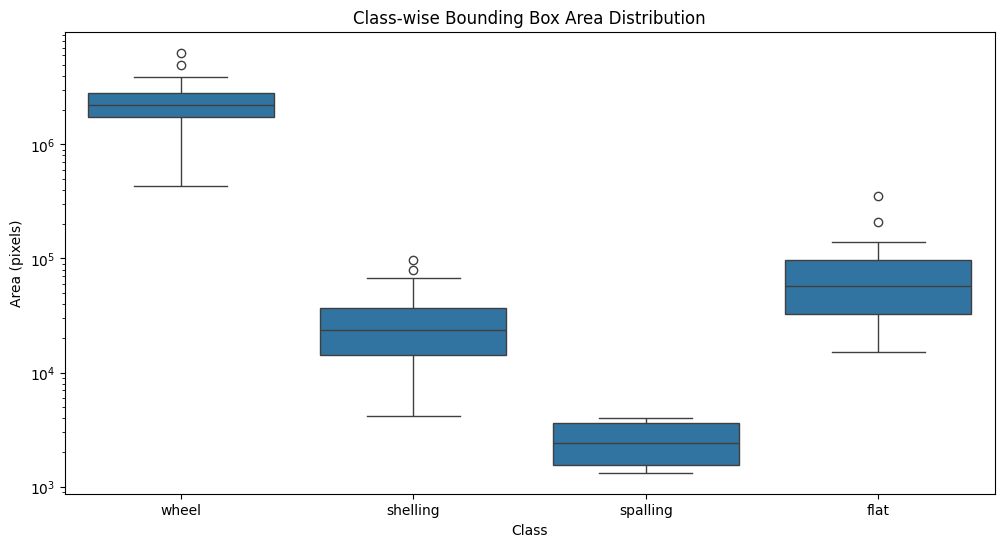

In [45]:
# 면적(area) 분포: 클래스별 박스플롯
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_LR, x='category_name', y='area')
plt.title('Class-wise Bounding Box Area Distribution')
plt.xlabel('Class')
plt.ylabel('Area (pixels)')
plt.yscale('log')  # 큰 차이로 로그 스케일 적용
plt.show()

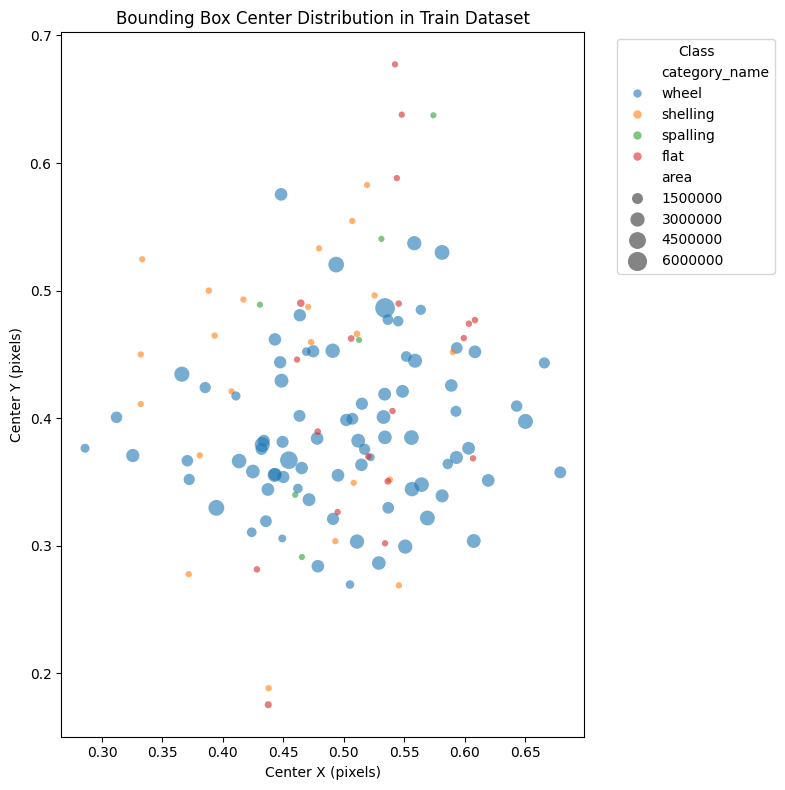

In [46]:
df = df_LR.rename(columns={
        'x_center':'center_x', 'y_center':'center_y',
        'width':'bbox_width', 'height':'bbox_height'
    })


plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df,
    x='center_x', y='center_y',
    hue='category_name',
    size='area', sizes=(20, 200),
    alpha=0.6, edgecolor='none'
)
plt.title('Bounding Box Center Distribution in Train Dataset')
plt.xlabel('Center X (pixels)')
plt.ylabel('Center Y (pixels)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Class')
plt.tight_layout()
plt.show()

In [12]:
# filepath: /Users/dongbae/Dev/WheelScan/scripts/check_labels.py
import glob

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
max_class = 5  # 클래스 인덱스 최대값 (클래스가 4개면 3)
print(f"총 라벨 파일 수: {len(label_files)}")

for file in label_files:
    with open(file) as f:
        for i, line in enumerate(f):
            if line.strip() == '':
                continue
            cls = int(line.split()[0])
            if cls < 0 or cls > max_class:
                print(f"잘못된 클래스 인덱스: {file} line {i+1} -> {cls}")

총 라벨 파일 수: 0


In [20]:
import glob

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
empty_files = []
for file in label_files:
    with open(file) as f:
        lines = [line for line in f if line.strip()]
        if len(lines) == 0:
            empty_files.append(file)
print(f"비어있는 라벨 파일 수: {len(empty_files)}")
for f in empty_files:
    print(f)

비어있는 라벨 파일 수: 0


In [21]:
import glob

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
found = False
for file in label_files:
    with open(file) as f:
        for i, line in enumerate(f):
            if line.strip() == '':
                continue
            cls = int(line.split()[0])
            if cls == 4:
                print(f"4번 그룹 라벨 발견: {file} line {i+1} -> {line.strip()}")
                found = True
if not found:
    print("4번 그룹 라벨이 없습니다.")

4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/D0010_JPG.rf.ec4c98c6a923f4391665c35304e1f54a.txt line 1 -> 4 0.4697818181818182 0.5144554455445545 0.22014545454545456 0.2956930693069306
4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/R0716_jpg.rf.0889bd7779c7909be15bd1eaf6f701e3.txt line 2 -> 4 0.5311624649859944 0.5405427170868348 0.008520074696545284 0.006635154061624586
4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/D0104_jpg.rf.65169b47cf91f36118908ffa0a2bdbd2.txt line 1 -> 4 0.47707812499999996 0.43125 0.05625 0.05416666666666667
4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/D0104_jpg.rf.65169b47cf91f36118908ffa0a2bdbd2.txt line 2 -> 4 0.5333281249999999 0.3625 0.05 0.0472291666666667
4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/D0123_jpg.rf.2739ff529b3eb17ffe15e02679709338.txt line 1 -> 4 0.54875 0.4233506944444445 0.20056640624999994 0.31250000000000006
4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/

In [6]:
import glob
from collections import Counter

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
class_counter = Counter()

for file in label_files:
    with open(file) as f:
        for line in f:
            if line.strip() == '':
                continue
            cls = int(line.split()[0])
            class_counter[cls] += 1

for cls in range(6):
    print(f"{cls}번 그룹 라벨 개수: {class_counter[cls]}")

0번 그룹 라벨 개수: 636
1번 그룹 라벨 개수: 295
2번 그룹 라벨 개수: 805
3번 그룹 라벨 개수: 829
4번 그룹 라벨 개수: 0
5번 그룹 라벨 개수: 0


In [22]:
import glob

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
for file in label_files:
    with open(file) as f:
        for i, line in enumerate(f):
            if line.strip() == '':
                continue
            cls = int(line.split()[0])
            if cls < 0:
                print(f"음수 클래스 인덱스 발견: {file} line {i+1} -> {cls}")

In [8]:
import glob
import math

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
for file in label_files:
    with open(file) as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) < 5:
                print(f"좌표값 부족: {file} line {i+1} -> {line.strip()}")
                continue
            try:
                vals = [float(x) for x in parts]
                if any(math.isnan(x) or math.isinf(x) for x in vals):
                    print(f"NaN/inf 포함: {file} line {i+1} -> {line.strip()}")
            except Exception as e:
                print(f"숫자 변환 오류: {file} line {i+1} -> {line.strip()} ({e})")

In [23]:
import os
from glob import glob

img_dir = '/Users/dongbae/Dev/WheelScan/data/valid/images'
label_dir = '/Users/dongbae/Dev/WheelScan/data/valid/labels'

img_files = glob(os.path.join(img_dir, '*'))
img_basenames = [os.path.splitext(os.path.basename(f))[0] for f in img_files]

missing_labels = []
for name in img_basenames:
    label_path = os.path.join(label_dir, name + '.txt')
    if not os.path.exists(label_path):
        missing_labels.append(name)

print(f"라벨 없는 validation 이미지 수: {len(missing_labels)}")
for name in missing_labels:
    print(name)

라벨 없는 validation 이미지 수: 0


In [26]:
import glob
from collections import Counter

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/train/labels/*.txt')
class_counter = Counter()

for file in label_files:
    with open(file) as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                class_counter[cls] += 1

for cls in range(6):  # 클래스 인덱스 0~3
    print(f"{cls}번 클래스 라벨 개수: {class_counter[cls]}")

0번 클래스 라벨 개수: 35
1번 클래스 라벨 개수: 1
2번 클래스 라벨 개수: 40
3번 클래스 라벨 개수: 23
4번 클래스 라벨 개수: 318
5번 클래스 라벨 개수: 82


In [15]:
import glob
from collections import Counter

label_dir = '/Users/dongbae/Dev/WheelScan/data/train/labels'
label_files = glob.glob(f'{label_dir}/*.txt')

# 파일별 1번 클래스 개수 저장
file_class_count = []

for file in label_files:
    with open(file) as f:
        class_counter = Counter(int(line.split()[0]) for line in f if line.strip())
        file_class_count.append((file, class_counter[1]))  # 1번 클래스 개수 저장

# 1번 클래스 개수로 정렬 후 상위 10개 출력
file_class_count.sort(key=lambda x: x[1], reverse=True)
top_10_files = file_class_count[:10]

print("1번 클래스 라벨이 많은 파일 상위 10개:")
for file, count in top_10_files:
    print(f"{file}: {count}개")

1번 클래스 라벨이 많은 파일 상위 10개:
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1505_jpg.rf.71c2ea9d528ac0bb70abbb630e9b79c1.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1503_jpg.rf.24a789ab8209a098fece3b7534084397.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1505_jpg.rf.64b969e8cc57dd6c1fee2cf96fe109e7.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1505_jpg.rf.2be66ec92a6439beb750c437b848e4a3.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1501_jpg.rf.0a74c103b49ff55598ff38febd944c7c.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1505_jpg.rf.a4aae779a90ce45cb8654053cb55f97c.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1501_jpg.rf.c6a03c211eff7b1a8cb410870cd36679.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1501_jpg.rf.389ff85f483a9acd030a2f1672645d11.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1503_jpg.rf.576ba64723392ce05449770981bb5384.txt: 3개
/Users/dongbae/Dev/WheelScan/d

In [ ]:
import os
from glob import glob

img_dir = '/Users/dongbae/Dev/WheelScan/data/valid/images'
label_dir = '/Users/dongbae/Dev/WheelScan/data/valid/labels'

img_files = glob(os.path.join(img_dir, '*'))
img_basenames = [os.path.splitext(os.path.basename(f))[0] for f in img_files]

missing_labels = []
for name in img_basenames:
    label_path = os.path.join(label_dir, name + '.txt')
    if not os.path.exists(label_path):
        missing_labels.append(name)

print(f"라벨 없는 validation 이미지 수: {len(missing_labels)}")
for name in missing_labels:
    print(name)

라벨 없는 validation 이미지 수: 0
